In [1]:
import pandas as pd


df_raw = pd.read_csv("data/SuperStoreOrders.csv")
df = df_raw.copy()
df["sales"] = (
    df["sales"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
)

df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["margin"] = df["profit"] / df["sales"]

df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True, errors="coerce")
df["ship_date"]  = pd.to_datetime(df["ship_date"],  format="mixed", dayfirst=True, errors="coerce")
df["shipping_delay"] = (df["ship_date"] - df["order_date"]).dt.days

In [2]:
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,margin,shipping_delay
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011,0.260147,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011,0.300300,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011,0.449091,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011,-0.579000,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011,0.331316,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-01-04,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014,0.322771,4
51286,MO-2014-2560,2014-12-31,2015-01-05,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014,0.105000,5
51287,MX-2014-110527,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014,0.475385,2
51288,MX-2014-114783,2014-12-31,2015-01-06,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014,0.080000,6


In [3]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year,margin,shipping_delay
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,5.129000e+04,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208,-inf,3.969370
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,-inf,0.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,0.000000e+00,3.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,1.692552e-01,4.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,3.331303e-01,5.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000,5.828000e-01,7.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931,NaN,1.729437


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

# EDA Market Basket

In [6]:
df[["order_id","product_name"]].head()

,order_id,product_name
0,AG-2011-2040,"Tenex Lockers, Blue"
1,IN-2011-47883,"Acme Trimmer, High Speed"
2,HU-2011-1220,"Tenex Box, Single Width"
3,IT-2011-3647632,"Enermax Note Cards, Premium"
4,IN-2011-47883,"Eldon Light Bulb, Duo Pack"


In [14]:
print("Rows:", len(df))
print("Unique orders:", df["order_id"].nunique())
print("Unique products:", df["product_name"].nunique())

Rows: 51290
Unique orders: 25035
Unique products: 3788


In [16]:
big_order = (
    df.groupby("order_id")["product_name"]
    .nunique()
    .sort_values(ascending=False)
    .index[0]
)

big_order

'CA-2014-100111'

In [17]:
df[df["order_id"] == big_order][["order_id","product_name"]]

,order_id,product_name
44726,CA-2014-100111,Hon 4070 Series Pagoda Armless Upholstered Sta...
44727,CA-2014-100111,Global Troy Executive Leather Low-Back Tilter
44728,CA-2014-100111,Apple iPhone 5
44730,CA-2014-100111,Hon Valutask Swivel Chairs
44731,CA-2014-100111,Logitech Wireless Boombox Speaker - portable -...
44732,CA-2014-100111,Plantronics Cordless Phone Headset with In-lin...
44733,CA-2014-100111,"Global Leather Task Chair, Black"
44735,CA-2014-100111,Logitech LS21 Speaker System - PC Multimedia -...
44736,CA-2014-100111,SanDisk Cruzer 64 GB USB Flash Drive
44738,CA-2014-100111,"SimpliFile Personal File, Black Granite, 15w x..."


In [18]:
basket_size = df.groupby("order_id")["product_name"].nunique()

basket_size.describe()

count    25035.000000
mean         2.047054
std          1.466798
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: product_name, dtype: float64

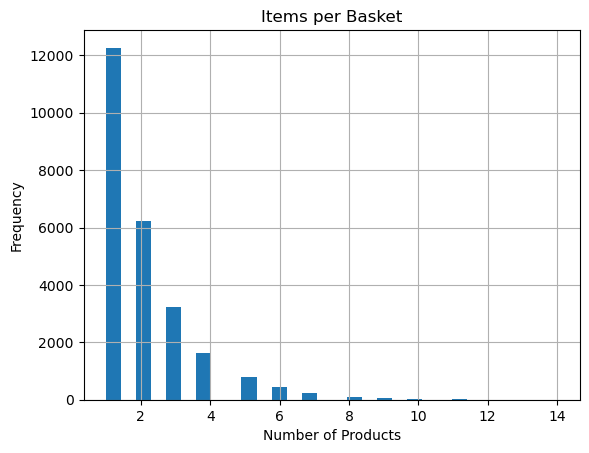

In [19]:
import matplotlib.pyplot as plt

basket_size.hist(bins=30)
plt.title("Items per Basket")
plt.xlabel("Number of Products")
plt.ylabel("Frequency")
plt.show()

In [20]:
top_products = (
    df["product_name"]
    .value_counts()
    .head(20)
)

top_products

product_name
Staples                                         227
Cardinal Index Tab, Clear                        92
Eldon File Cart, Single Width                    90
Rogers File Cart, Single Width                   84
Ibico Index Tab, Clear                           83
Sanford Pencil Sharpener, Water Color            80
Smead File Cart, Single Width                    77
Acco Index Tab, Clear                            75
Stanley Pencil Sharpener, Water Color            75
Avery Index Tab, Clear                           74
Tenex File Cart, Single Width                    70
Stockwell Paper Clips, Assorted Sizes            65
Boston Pencil Sharpener, Water Color             59
Binney & Smith Pencil Sharpener, Water Color     55
Stockwell Thumb Tacks, 12 Pack                   53
Wilson Jones 3-Hole Punch, Durable               52
Avery Binder Covers, Recycled                    52
Binney & Smith Sketch Pad, Blue                  52
Cardinal Binding Machine, Economy                52

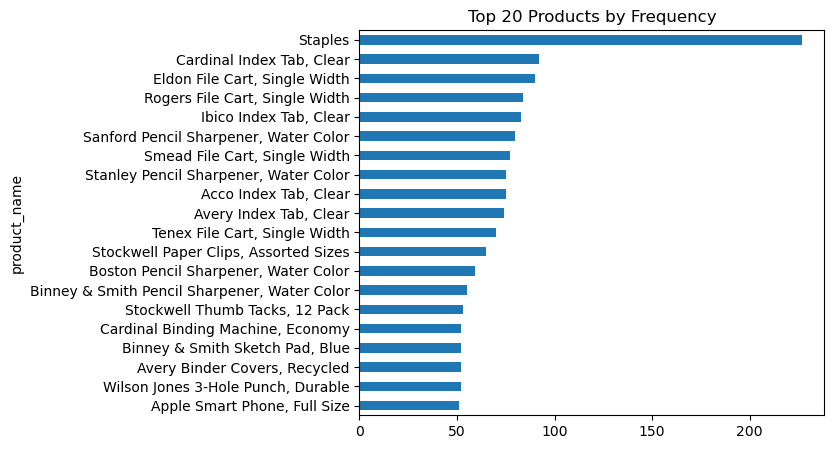

In [21]:
top_products.sort_values().plot(kind="barh", figsize=(6,5))
plt.title("Top 20 Products by Frequency")
plt.show()

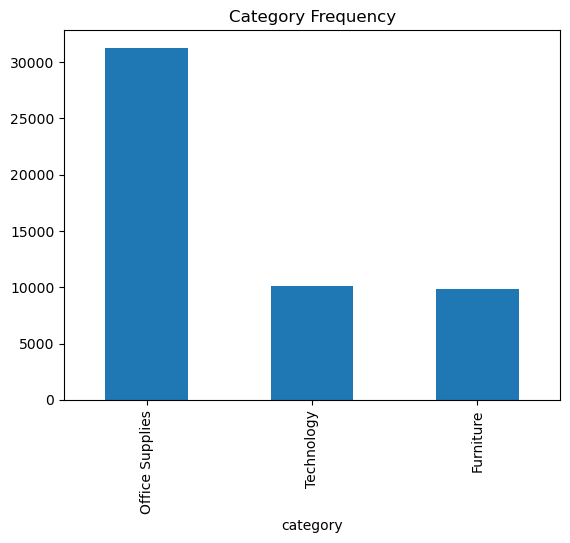

In [22]:
df["category"].value_counts().plot(kind="bar")
plt.title("Category Frequency")
plt.show()

In [23]:
df[["sales","profit","discount"]].describe()

,sales,profit,discount
count,51290.000000,51290.000000,51290.000000
mean,246.498440,28.641740,0.142908
std,487.567175,174.424113,0.212280
min,0.000000,-6599.978000,0.000000
25%,31.000000,0.000000,0.000000
50%,85.000000,9.240000,0.000000
75%,251.000000,36.810000,0.200000
max,22638.000000,8399.976000,0.850000


In [24]:
basket = (
    df.groupby(["order_id","product_name"])
      .size()
      .unstack(fill_value=0)
)

basket.head()

product_name,"""While you Were Out"" Message Book, One Form per Page","#10 Gummed Flap White Envelopes, 100/Box",#10 Self-Seal White Envelopes,"#10 White Business Envelopes,4 1/8 x 9 1/2","#10- 4 1/8"" x 9 1/2"" Recycled Envelopes","#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes","#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Envelopes",#6 3/4 Gummed Flap White Envelopes,"1.7 Cubic Foot Compact ""Cube"" Office Refrigerators","1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2"" X 11"" Cards, 25 Env./Pack",...,Zebra ZM400 Thermal Label Printer,Zebra Zazzle Fluorescent Highlighters,Zipper Ring Binder Pockets,i.Sound Portable Power - 8000 mAh,iHome FM Clock Radio with Lightning Dock,"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",iOttie HLCRIO102 Car Mount,iOttie XL Car Mount,invisibleSHIELD by ZAGG Smudge-Free Screen Protector,netTALK DUO VoIP Telephone Service
order_id,,,,,,,,,,,,,,,,,,,,,
AE-2011-9160,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AE-2013-1130,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AE-2013-1530,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AE-2014-2840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AE-2014-3830,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df.groupby(["customer_name","segment"])["order_id"].nunique().sort_values(ascending=False).head(10)

customer_name     segment    
Anna Andreadi     Consumer       47
Frank Olsen       Consumer       47
Michael Paige     Corporate      47
Laura Armstrong   Corporate      46
Kristen Hastings  Corporate      46
Sara Luxemburg    Home Office    46
Tracy Blumstein   Consumer       45
Noel Staavos      Corporate      45
Gary Hansen       Home Office    45
Eric Murdock      Consumer       45
Name: order_id, dtype: int64

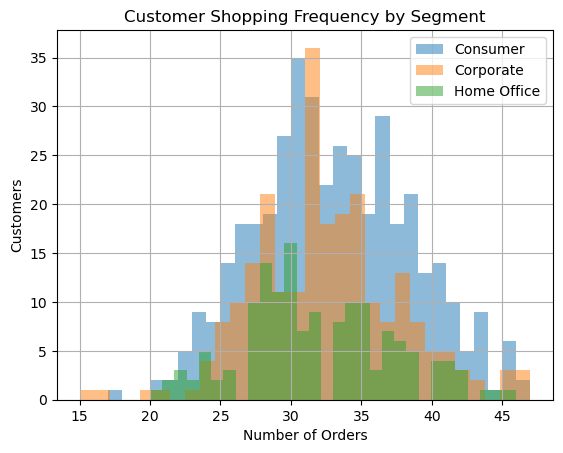

In [13]:
import matplotlib.pyplot as plt
cust_freq = (
    df.groupby(["customer_name", "segment"])["order_id"]
      .nunique()
      .reset_index(name="num_orders")
)

cust_freq.head()
for seg in cust_freq["segment"].unique():
    cust_freq[cust_freq["segment"] == seg]["num_orders"].hist(
        bins=30,
        alpha=0.5,
        label=seg
    )

plt.legend()
plt.title("Customer Shopping Frequency by Segment")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.show()